C:\Users\Fager\AppData\Local\Temp\ipykernel_17680\1764790268.py:72: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  flows_df.groupby("FlowBin")["Ensemble"]


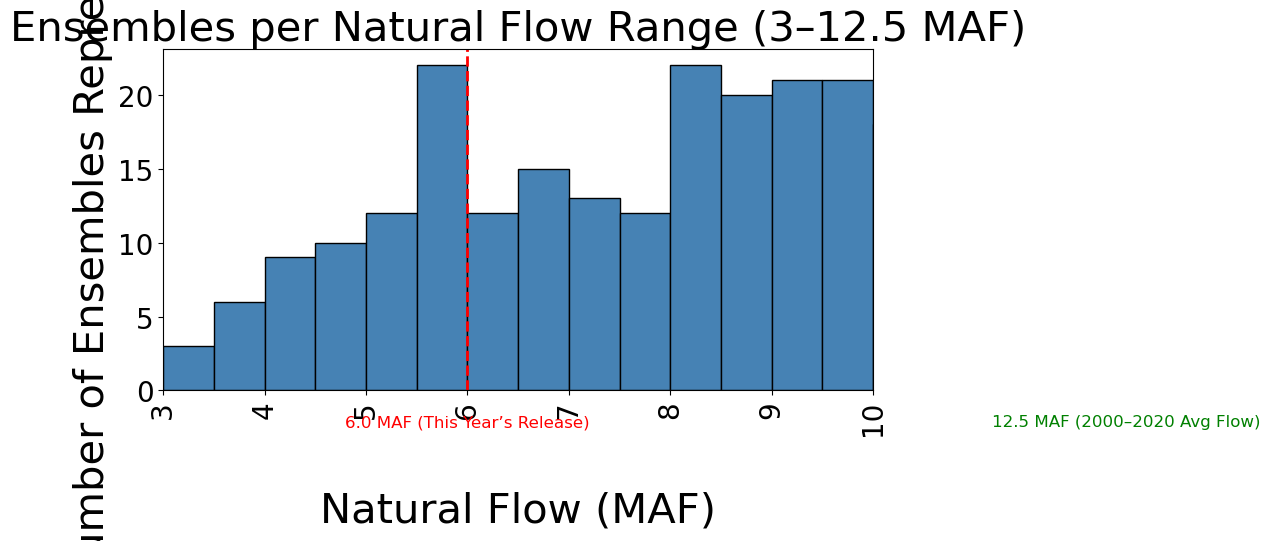

In [74]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt


# 1. READ INPUTS & SHEET NAMES


code_file = Path().resolve()
input_file = code_file / "HydrologyScenarios.xlsx"

excluded_sheets = [
    "ReadMe", "AvailableHydrologyScenarios", "ScenarioListForAnalysis",
    "AvailableMetrics", "MetricsForAnalysis", "Heatmap", "Hist"
]

sheet_names = pd.ExcelFile(input_file).sheet_names


# 2. EXTRACT ALL ANNUAL FLOWS FROM ALL ENSEMBLES


flow_records = []

for ensemble_name in sheet_names:
    if ensemble_name in excluded_sheets:
        continue

    df = pd.read_excel(input_file, sheet_name=ensemble_name)
    df = df.apply(pd.to_numeric, errors="coerce")

    years = df.iloc[:, 0]          # first column = year
    traces = df.columns[1:]        # remaining columns = traces

    for trace in traces:
        series = df[trace].dropna().reset_index(drop=True)

        for i, value in enumerate(series):
            flow_records.append({
                "Ensemble": ensemble_name,
                "Trace": trace,
                "YearIndex": i,
                "Year": years.iloc[i],
                "Flow": value
            })

flows_df = pd.DataFrame(flow_records)

# Remove zero flows
flows_df = flows_df[flows_df["Flow"] != 0]


# 3. DEFINE 0.5-MAF FLOW BINS (0–0.5, 0.5–1.0, ..., 12.0–12.5)


flow_bins = np.arange(0, 13 + 0.5, 0.5)   # 0, 0.5, 1.0, ..., 12.5
flow_labels = [f"{flow_bins[i]}" for i in range(len(flow_bins)-1)]

flows_df["FlowBin"] = pd.cut(
    flows_df["Flow"],
    bins=flow_bins,
    labels=flow_labels,
    include_lowest=True
)


# 4. COUNT UNIQUE ENSEMBLES PER FLOW BIN


ensemble_counts = (
    flows_df.groupby("FlowBin")["Ensemble"]
    .nunique()
    .reset_index(name="NumEnsembles")
)

ensemble_counts["FlowBinNum"] = ensemble_counts["FlowBin"].astype(float)


# 5. FILTER TO 3.0–12.5 MAF RANGE


filtered = ensemble_counts[
    (ensemble_counts["FlowBinNum"] >= 3.0) &
    (ensemble_counts["FlowBinNum"] <= 12.5)
].copy()

filtered = filtered.sort_values("FlowBinNum")


# 6. PLOT FINAL FIGURE


plt.figure(figsize=(14, 6))

# Bar centers for 0.5-MAF bins
bar_positions = filtered["FlowBinNum"] + 0.25

plt.bar(
    bar_positions,
    filtered["NumEnsembles"],
    width=0.5,
    color="steelblue",
    edgecolor="black"
)

# Reference lines
plt.axvline(x=6.0, color="red", linestyle="--", linewidth=2)
plt.axvline(x=12.5, color="green", linestyle="--", linewidth=2)

# Labels below axis
ymin, ymax = plt.ylim()

plt.text(
    x=6.0,
    y=ymin - (0.07 * ymax),
    s="6.0 MAF (This Year’s Release)",
    ha="center",
    va="top",
    fontsize=12,
    color="red"
)

plt.text(
    x=12.5,
    y=ymin - (0.07 * ymax),
    s="12.5 MAF (2000–2020 Avg Flow)",
    ha="center",
    va="top",
    fontsize=12,
    color="green"
)

plt.xlabel("Natural Flow (MAF)", labelpad=40)
plt.ylabel("Number of Ensembles Represented")
plt.title("Ensembles per Natural Flow Range (3–12.5 MAF)")

tick_positions = np.arange(3, 13, 1)
plt.xticks(ticks=tick_positions, labels=[str(x) for x in tick_positions], rotation=90)

plt.xlim(3, 10)
plt.gcf().subplots_adjust(bottom=0.25)
plt.tight_layout()
plt.show()


In [77]:
#read in inputs

code_file = Path().resolve()
input_file = code_file / 'HydrologyScenarios.xlsx'
elev_cap_file = code_file / 'Lake_Powell_2018_ElevAreaCap_calc.csv'

excluded_sheets = [
    "ReadMe", "AvailableHydrologyScenarios", "ScenarioListForAnalysis",
    "AvailableMetrics", "MetricsForAnalysis", "Heatmap", "Hist"
]

sheet_names = pd.ExcelFile(input_file).sheet_names

all_series = []

for ensemble_name in sheet_names:
    if ensemble_name in excluded_sheets:
        continue

    df = pd.read_excel(input_file, sheet_name=ensemble_name)
    df = df.apply(pd.to_numeric, errors='coerce')

    years = df.iloc[:, 0]          # first column = year
    traces = df.columns[1:]        # remaining columns = traces

    for trace in traces:
        series = df[trace].dropna().reset_index(drop=True)

        for i, value in enumerate(series):
            all_series.append({
                "Ensemble": ensemble_name,
                "Trace": trace,
                "YearIndex": i,
                "Year": years.iloc[i],
                "Inflow_MAF": value
            })

inflow_df = pd.DataFrame(all_series)

ANNUAL_RELEASE_MAF = 8.3  # change this as needed

inflow_df["Release_MAF"] = ANNUAL_RELEASE_MAF

# Sort to ensure correct ordering
df = inflow_df.sort_values(["Ensemble", "Trace", "YearIndex"]).copy()

# Compute next year's flow
df["NextFlow_MAF"] = (
    df.groupby(["Ensemble", "Trace"])["Inflow_MAF"].shift(-1)
)

# Compute next year's index
df["NextYearIndex"] = (
    df.groupby(["Ensemble", "Trace"])["YearIndex"].shift(-1)
)

# Compute year-to-year difference
df["Difference_MAF"] = df["NextFlow_MAF"] - df["Inflow_MAF"]

# Keep only valid pairs (i.e., where next year exists)
pair_df = df.dropna(subset=["NextFlow_MAF"]).copy()

# Select final columns
pair_df = pair_df[[
    "Ensemble",
    "Trace",
    "YearIndex",
    "NextYearIndex",
    "Inflow_MAF",
    "NextFlow_MAF",
    "Difference_MAF"
]]

pair_df.to_csv("AllHydrology_YearToYearPairs.csv", index=False)

In [78]:

# Load data
pairs = pd.read_csv("AllHydrology_YearToYearPairs.csv")

# Explicit numeric conversion only for numeric fields
numeric_cols = ["YearIndex", "NextYearIndex", "Inflow_MAF", "NextFlow_MAF", "Difference_MAF"]
pairs[numeric_cols] = pairs[numeric_cols].apply(pd.to_numeric, errors="coerce")

# Filter conditions (same as before)
pairs_filtered = pairs[
    (pairs["Inflow_MAF"] < 12.5) &
    (pairs["Difference_MAF"] < 0) &
    (pairs["NextFlow_MAF"] > 0)
].copy()

# Convert drops to magnitudes
pairs_filtered["DropMagnitude"] = pairs_filtered["Difference_MAF"].abs()

# Define magnitude bins (0 to 13 MAF)
drop_bins = np.arange(0, 14, 1)   # 0–1, 1–2, ..., 12–13
drop_labels = [f"{drop_bins[i]} to {drop_bins[i+1]}" for i in range(len(drop_bins)-1)]

# Bin the magnitudes
pairs_filtered["DropBin"] = pd.cut(
    pairs_filtered["DropMagnitude"],
    bins=drop_bins,
    labels=drop_labels,
    include_lowest=True
)

# Count ensembles per magnitude bin (including empty bins)
ensemble_drop_counts = (
    pairs_filtered.groupby("DropBin")["Ensemble"]
    .nunique()
    .reindex(pairs_filtered["DropBin"].cat.categories, fill_value=0)
    .reset_index(name="NumEnsembles")
)

# Compute bin centers for plotting
bin_edges = drop_bins
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

print(ensemble_drop_counts)


       index  NumEnsembles
0     0 to 1            22
1     1 to 2            22
2     2 to 3            22
3     3 to 4            18
4     4 to 5            18
5     5 to 6            22
6     6 to 7            14
7     7 to 8             6
8     8 to 9             2
9    9 to 10             1
10  10 to 11             0
11  11 to 12             0
12  12 to 13             0


C:\Users\Fager\AppData\Local\Temp\ipykernel_17680\2646178765.py:32: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pairs_filtered.groupby("DropBin")["Ensemble"]


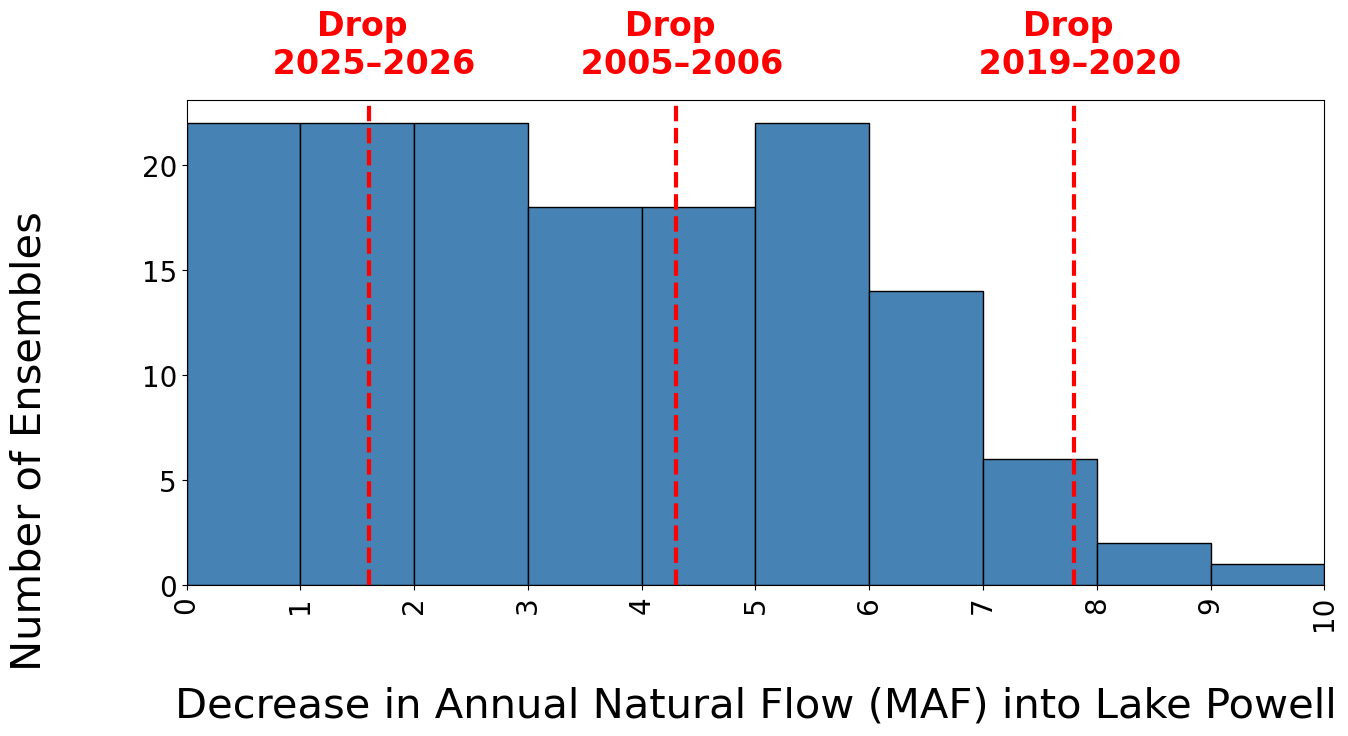

In [79]:
import matplotlib.pyplot as plt

# Increase global font sizes
plt.rcParams.update({
    "font.size": 26,          # base font size
    "axes.titlesize": 30,     # title
    "axes.labelsize": 30,     # x/y labels
    "xtick.labelsize": 20,    # x ticks
    "ytick.labelsize": 20,    # y ticks
    "legend.fontsize": 30
})

fig = plt.figure(figsize=(14, 8))
ax = fig.add_subplot(111)

# MAIN BAR PLOT
ax.bar(
    bin_centers,
    ensemble_drop_counts["NumEnsembles"],
    width=1.0,
    color="steelblue",
    edgecolor="black"
)

ax.set_xticks(bin_edges)
ax.set_xticklabels([str(e) for e in bin_edges], rotation=90)

ax.set_xlabel("Decrease in Annual Natural Flow (MAF) into Lake Powell", labelpad=40)
ax.set_ylabel("Number of Ensembles", labelpad=40)
ax.yaxis.set_label_coords(-0.12, 0.3)


# X‑AXIS FROM 0 TO 10

ax.set_xlim(0, 10)


# VERTICAL LINES

ax.axvline(x=1.6, color="red", linestyle="--", linewidth=3)
ax.axvline(x=7.8, color="red", linestyle="--", linewidth=3)
ax.axvline(x=4.3, color="red", linestyle="--", linewidth=3)


# TEXT ABOVE THE AXES BOX (CENTERED)

def data_x_to_axes_x(ax, x):
    """Convert a data x-value to axes coordinates (0–1)."""
    return ax.transAxes.inverted().transform(
        ax.transData.transform((x, 0))
    )[0]

labels = [
    (1.6, "Drop \n 2025–2026"),
    (7.8, "Drop \n 2019–2020"),
    (4.3, "Drop \n 2005–2006")
]

for x, text in labels:
    ax_x = data_x_to_axes_x(ax, x)
    ax.text(
        ax_x,
        1.04,   # slightly above the axes box
        text,
        ha="center",
        va="bottom",
        color="red",
        fontsize=24,
        fontweight="bold",
        transform=ax.transAxes
    )

plt.tight_layout()
plt.show()
